In [8]:
import pandas as pd
import numpy as np
import seaborn as sns
import scipy.stats as st
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split, GridSearchCV, GroupKFold, cross_val_score
from sklearn.model_selection import GroupShuffleSplit
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestRegressor
from sklearn.decomposition import PCA
from sklearn.metrics import r2_score, mean_absolute_error
from sklearn.compose import TransformedTargetRegressor
import plotly.express as px
import os
import warnings
import shap
warnings.filterwarnings('ignore')
%matplotlib inline

print("Cargando el Excel 'Sistema_LAP.xlsx' y procesando datos...")

archivo_objetivo = 'Sistema_LAP.xlsx'
col_young = 'Young Modulus (Kpa)'
col_err_rel = 'Error Relativo (%)'

# 1. Carga inicial saltando las cabeceras sobrantes
df_crudo = pd.read_excel(archivo_objetivo, skiprows=1)
df_crudo.columns = df_crudo.columns.str.strip()

# 2. Limpieza estricta de textos residuales ('ERROR', 'NG', etc.) en la columna objetivo
df_crudo['Valor_Temp'] = df_crudo[col_young].astype(str).str.strip().str.upper()
df_inicial = df_crudo[~df_crudo['Valor_Temp'].isin(['NG', 'ERROR', 'NAN', 'NONE', 'NULL', ''])].copy()
df_inicial = df_inicial.drop(columns=['Valor_Temp']) # Limpiamos la columna auxiliar

# 3. Aseguramos formato numérico y eliminamos nulos físicos
df_inicial[col_young] = pd.to_numeric(df_inicial[col_young], errors='coerce')
df_inicial[col_err_rel] = pd.to_numeric(df_inicial[col_err_rel], errors='coerce')
df_medible = df_inicial.dropna(subset=[col_young, col_err_rel]).copy()

# =====================================================================
# FILTRADO POR ERROR RELATIVO INSTRUMENTAL
# =====================================================================
def filtrar_por_error_relativo(grupo, threshold_error=25.0):

    mascara_validos = grupo[col_err_rel] <= threshold_error
    return grupo[mascara_validos]

# Agrupamos por composición + tiempo de inmersión para mantener la consistencia cinética
df_super_limpio = (
    df_medible
    .groupby(['PEGDA (%)', 'LAP (%)', 'Tiempo Sumergido (min)'], group_keys=False)
    .apply(filtrar_por_error_relativo)
)

# =====================================================================
# REPORTE
# =====================================================================
n_antes = len(df_medible)
n_despues = len(df_super_limpio)

print("\nREPORTE DE CALIDAD INSTRUMENTAL (Filtro Error Relativo <= 25%)")
print("==================================================================")
print(f"Muestras iniciales legibles:        {n_antes}")
print(f"Muestras finales válidas:           {n_despues}")
print(f"Muestras eliminadas por alto ruido: {n_antes - n_despues}")
print(f"Porcentaje de descarte:             {(n_antes - n_despues)/n_antes*100:.2f}%")
print("==================================================================")

Cargando el Excel 'Sistema_LAP2.xlsx' y procesando datos...

REPORTE DE CALIDAD INSTRUMENTAL (Filtro Error Relativo <= 25%)
Muestras iniciales legibles:        255
Muestras finales válidas:           198
Muestras eliminadas por alto ruido: 57
Porcentaje de descarte:             22.35%


Generando análisis de Productividad de la Librería Completa (288 muestras / 3 Placas)...


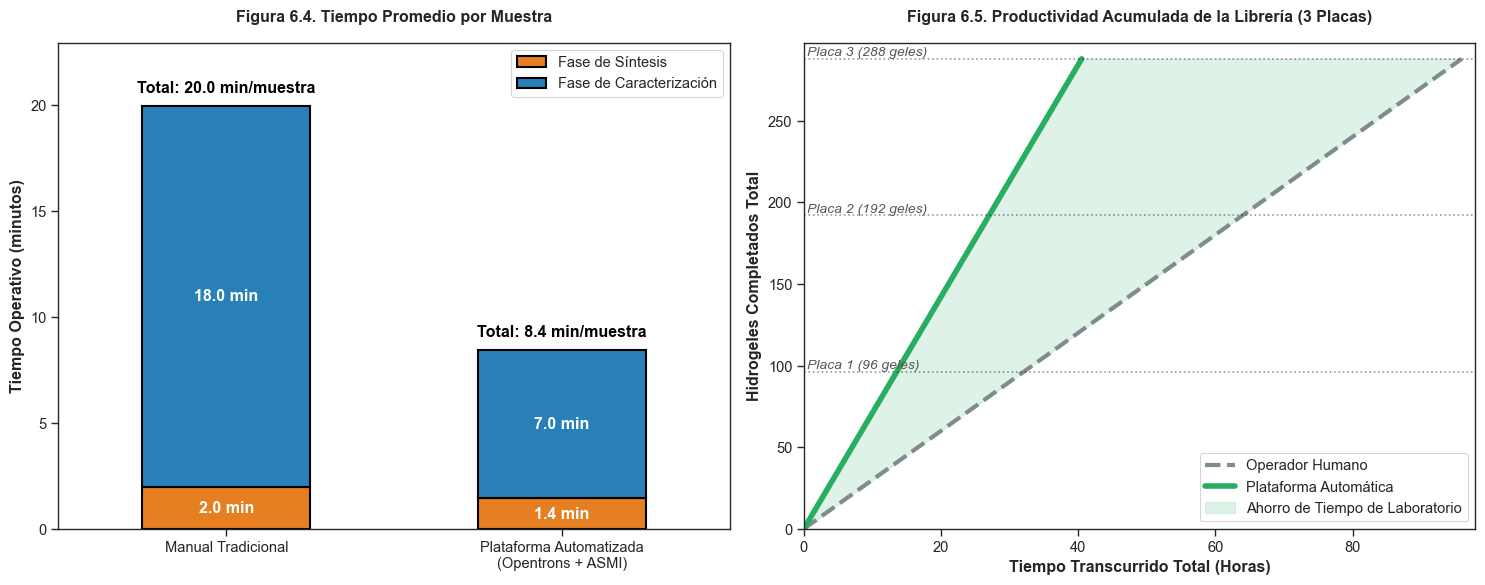


 📊 DATOS FINALES UNIFICADOS PARA LA DEFENSA DE TU TESIS
📌 CONTROL DE CALIDAD DE LA LIBRERÍA (DATA CLEANING):
- Volumen inicial de la librería: 255 probetas ensayadas.
- Fallos críticos de lectura (No gelificación o Módulo de Young inferior al límite de detección del ASMI): 0 muestras.
- Respuestas mecánicas aberrantes filtradas (Filtro robusto MAD): 57 muestras.
- Datos puros exportados a Machine Learning: 198 (77.6%)

📌 RENDIMIENTO OPERATIVO REAL:
- Rendimiento de caracterización del ASMI: 23.0 muestras/hora.
- Tiempo estimado para procesar las 3 placas a mano: 95.9 horas.
- Tiempo de ejecución con la plataforma: 40.5 horas.
🔥 AHORRO NETO: 55.4 horas de trabajo de laboratorio.
📈 FACTOR DE ACELERACIÓN: Reducción del 57.8% del tiempo de screening.


In [9]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import pandas as pd

print("Generando análisis de Productividad de la Librería Completa (288 muestras / 3 Placas)...")

# El Excel contiene el screening totalizado de las 3 placas
muestras_totales = 288  # 3 placas x 96 pocillos
n_placas = 3

# --- Tiempos Automatizados (Validados a 7 min/muestra en caract.) ---
t_sintesis_auto_total = (120 + 10 + 8) * n_placas  # Tiempo total para las 3 placas (min)
t_caract_auto_total = muestras_totales * 7.0       # ASMI total (min)

# --- Tiempos Manuales Estimados (Para las 288 muestras) ---
t_sintesis_manual_total = (180 + 10) * n_placas # Síntesis manual (min)
t_caract_manual_total = muestras_totales * 18.0      # Caracterización manual (min)

# Pasamos a "Tiempo promedio por muestra" para la gráfica de barras
t_sintesis_auto_m = t_sintesis_auto_total / muestras_totales
t_caract_auto_m = t_caract_auto_total / muestras_totales
t_total_auto_m = t_sintesis_auto_m + t_caract_auto_m

t_sintesis_manual_m = t_sintesis_manual_total / muestras_totales
t_caract_manual_m = t_caract_manual_total / muestras_totales
t_total_manual_m = t_sintesis_manual_m + t_caract_manual_m

# =====================================================================
# 2. PREPARACIÓN DE DATOS PARA LAS GRÁFICAS
# =====================================================================
df_tiempos = pd.DataFrame({
    'Flujo de Trabajo': ['Manual Tradicional', 'Plataforma Automatizada\n(Opentrons + ASMI)'],
    'Fase de Síntesis': [t_sintesis_manual_m, t_sintesis_auto_m],
    'Fase de Caracterización': [t_caract_manual_m, t_caract_auto_m]
})
df_tiempos.set_index('Flujo de Trabajo', inplace=True)

# Vectores de productividad (Acumulado de horas a lo largo de las 288 muestras)
horas_manual = (np.arange(0, muestras_totales + 1) * t_total_manual_m) / 60
horas_auto = (np.arange(0, muestras_totales + 1) * t_total_auto_m) / 60

# =====================================================================
# 3. DIBUJO DEL DOBLE PANEL
# =====================================================================
fig, axes = plt.subplots(1, 2, figsize=(15, 6))
sns.set_theme(style="ticks", context="paper", font_scale=1.2)

# --------- FIGURA : BARRAS APILADAS (Izquierda) ---------
colores = ['#E67E22', '#2980B9'] 

df_tiempos.plot(
    kind='bar', stacked=True, ax=axes[0], color=colores, 
    edgecolor='black', linewidth=1.5, width=0.5
)

for i, (idx, row) in enumerate(df_tiempos.iterrows()):
    axes[0].text(i, row['Fase de Síntesis'] / 2, f"{row['Fase de Síntesis']:.1f} min", 
                 ha='center', va='center', color='white', fontweight='bold')
    
    axes[0].text(i, row['Fase de Síntesis'] + (row['Fase de Caracterización'] / 2), 
                 f"{row['Fase de Caracterización']:.1f} min", 
                 ha='center', va='center', color='white', fontweight='bold')
    
    total = row['Fase de Síntesis'] + row['Fase de Caracterización']
    axes[0].text(i, total + 0.5, f"Total: {total:.1f} min/muestra", 
                 ha='center', va='bottom', color='black', fontweight='bold')

axes[0].set_title("Figura 6.4. Tiempo Promedio por Muestra", fontweight='bold', pad=15)
axes[0].set_ylabel("Tiempo Operativo (minutos)", fontweight='bold')
axes[0].set_xlabel("")
axes[0].tick_params(axis='x', rotation=0) 
axes[0].legend(loc='upper right')
axes[0].set_ylim(0, t_total_manual_m * 1.15)

# --------- FIGURA : CURVA DE PRODUCTIVIDAD---------
axes[1].plot(horas_manual, np.arange(0, muestras_totales + 1), 
             color='#7F8C8D', linewidth=3, linestyle='--', label='Operador Humano')
axes[1].plot(horas_auto, np.arange(0, muestras_totales + 1), 
             color='#27AE60', linewidth=4, label='Plataforma Automática')

# Sombreado del océano de horas ahorradas
axes[1].fill_betweenx(np.arange(0, muestras_totales + 1), horas_auto, horas_manual, 
                      color='#27AE60', alpha=0.15, label='Ahorro de Tiempo de Laboratorio')

# Líneas guía para las 3 placas de 96
for p in range(1, n_placas + 1):
    y_val = p * 96
    axes[1].axhline(y=y_val, color='black', linestyle=':', alpha=0.4)
    axes[1].text(0.5, y_val + 2, f'Placa {p} ({y_val} geles)', fontsize=10, style='italic', color='#555555')

axes[1].set_title("Figura 6.5. Productividad Acumulada de la Librería (3 Placas)", fontweight='bold', pad=15)
axes[1].set_ylabel("Hidrogeles Completados Total", fontweight='bold')
axes[1].set_xlabel("Tiempo Transcurrido Total (Horas)", fontweight='bold')
axes[1].legend(loc="lower right")

axes[1].set_xlim(0, max(horas_manual) + 2)
axes[1].set_ylim(0, muestras_totales + 10)

plt.tight_layout()
plt.savefig('Productividad_Real_Libreria_Completa.png', dpi=300, bbox_inches='tight')
plt.show()

# ============
# 4. REPORTE
# ============

tiempo_total_horas_real = (df_inicial['Tiempo Sumergido (min)'].max() - df_inicial['Tiempo Sumergido (min)'].min()) / 60
rendimiento_hora_muestras = len(df_inicial) / tiempo_total_horas_real if tiempo_total_horas_real > 0 else 0

h_manual = (t_total_manual_m * muestras_totales) / 60
h_auto = (t_total_auto_m * muestras_totales) / 60
ahorro = h_manual - h_auto
mejora_pct = ((h_manual - h_auto) / h_manual) * 100

print("\n" + "="*65)
print(" 📊 DATOS FINALES UNIFICADOS PARA LA DEFENSA DE TU TESIS")
print("="*65)
print("📌 CONTROL DE CALIDAD DE LA LIBRERÍA (DATA CLEANING):")
print(f"- Volumen inicial de la librería: {len(df_inicial)} probetas ensayadas.")
print(f"- Fallos críticos de lectura (No gelificación o Módulo de Young inferior al límite de detección del ASMI): {len(df_inicial) - len(df_medible)} muestras.")
print(f"- Respuestas mecánicas aberrantes filtradas (Filtro robusto MAD): {len(df_medible) - len(df_super_limpio)} muestras.")
print(f"- Datos puros exportados a Machine Learning: {len(df_super_limpio)} ({(len(df_super_limpio)/len(df_inicial))*100:.1f}%)")

print("\n📌 RENDIMIENTO OPERATIVO REAL:")
print(f"- Rendimiento de caracterización del ASMI: {rendimiento_hora_muestras:.1f} muestras/hora.")
print(f"- Tiempo estimado para procesar las 3 placas a mano: {h_manual:.1f} horas.")
print(f"- Tiempo de ejecución con la plataforma: {h_auto:.1f} horas.")
print(f"🔥 AHORRO NETO: {ahorro:.1f} horas de trabajo de laboratorio.")
print(f"📈 FACTOR DE ACELERACIÓN: Reducción del {mejora_pct:.1f}% del tiempo de screening.")

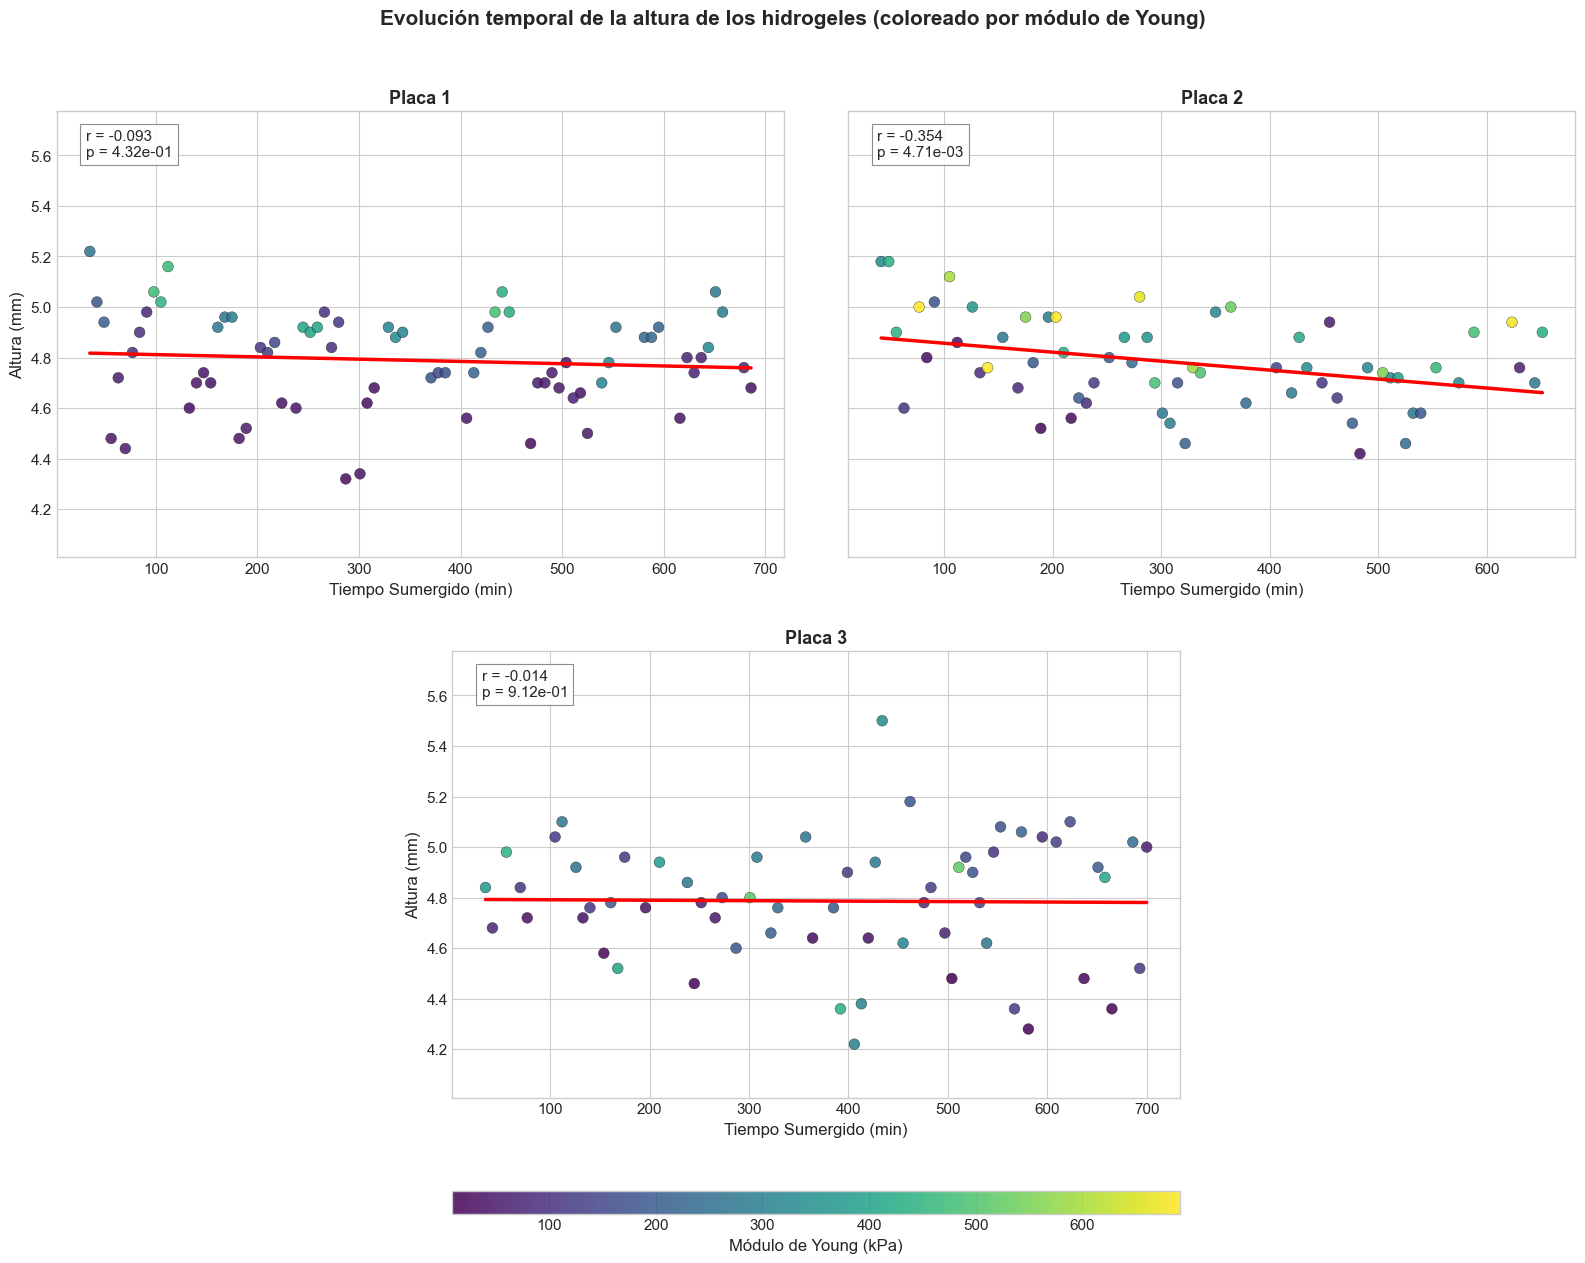

In [11]:
from sklearn.metrics import r2_score
from scipy.stats import pearsonr
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec

df_super_limpio['Tiempo Sumergido (min)'] = pd.to_numeric(df_super_limpio['Tiempo Sumergido (min)'], errors='coerce')
df_super_limpio['Altura (mm)'] = pd.to_numeric(df_super_limpio['Altura (mm)'], errors='coerce')
df_super_limpio[col_young] = pd.to_numeric(df_super_limpio[col_young], errors='coerce')

df_plot = df_super_limpio.replace([np.inf, -np.inf], np.nan).dropna(subset=['Tiempo Sumergido (min)', 'Altura (mm)', col_young])

plt.style.use('seaborn-v0_8-whitegrid')

fig = plt.figure(figsize=(16, 13)) 

gs = gridspec.GridSpec(3, 4, height_ratios=[1, 1, 0.05])        

ax1 = fig.add_subplot(gs[0, 0:2])
ax2 = fig.add_subplot(gs[0, 2:4], sharey=ax1)

ax3 = fig.add_subplot(gs[1, 1:3], sharey=ax1)

cax_colorbar = fig.add_subplot(gs[2, 1:3]) 

axes = [ax1, ax2, ax3]

plt.setp(ax2.get_yticklabels(), visible=False)

ymin = df_plot['Altura (mm)'].min() * 0.95
ymax = df_plot['Altura (mm)'].max() * 1.05

vmin = df_plot[col_young].min()
vmax = df_plot[col_young].max()

for ax, dia in zip(axes, sorted(df_plot['DIA ESTUDIO'].unique())):

    df_dia = df_plot[df_plot['DIA ESTUDIO'] == dia]

    sc = ax.scatter(
        df_dia['Tiempo Sumergido (min)'],
        df_dia['Altura (mm)'],
        c=df_dia[col_young],
        cmap='viridis',
        vmin=vmin,
        vmax=vmax,
        s=60,
        alpha=0.85,
        edgecolors='k',
        linewidths=0.3
    )

    x = df_dia['Tiempo Sumergido (min)'].values
    y = df_dia['Altura (mm)'].values

    if len(np.unique(x)) > 1 and len(x) > 2:
        coef = np.polyfit(x, y, 1)
        y_pred = np.polyval(coef, x)

        orden = np.argsort(x)

        ax.plot(
            x[orden],
            y_pred[orden],
            color='red',
            linewidth=2.5,
            label='Ajuste lineal'
        )

        r, p = pearsonr(x, y)

        ax.text(
            0.04,
            0.96,
            f'r = {r:.3f}\np = {p:.2e}',
            transform=ax.transAxes,
            va='top',
            fontsize=11,
            bbox=dict(facecolor='white', edgecolor='gray', alpha=0.9)
        )
    else:
        ax.text(
            0.04,
            0.96,
            'Datos insuficientes\npara regresión',
            transform=ax.transAxes,
            va='top',
            fontsize=11,
            color='red',
            bbox=dict(facecolor='white', edgecolor='red', alpha=0.9)
        )

    ax.set_title(f'Placa {int(dia)}', fontsize=13, fontweight='bold')
    ax.set_xlabel('Tiempo Sumergido (min)', fontsize=12)

    ax.set_ylim(ymin, ymax)
    ax.tick_params(axis='both', labelsize=11)

axes[0].set_ylabel('Altura (mm)', fontsize=12)
axes[2].set_ylabel('Altura (mm)', fontsize=12)

cbar = fig.colorbar(
    sc,
    cax=cax_colorbar,
    orientation='horizontal'
)

cbar.set_label('Módulo de Young (kPa)', fontsize=12)
cbar.ax.tick_params(labelsize=11)

plt.suptitle(
    'Evolución temporal de la altura de los hidrogeles (coloreado por módulo de Young)',
    fontsize=15,
    fontweight='bold',
    y=0.97
)

plt.tight_layout(rect=[0, 0, 1, 0.95], h_pad=2.0)

plt.savefig(
    'Figura_Altura_Tiempo_LAP.png',
    dpi=600,
    bbox_inches='tight'
)

plt.show()

Generando análisis de reproducibilidad unificado en una sola gráfica...


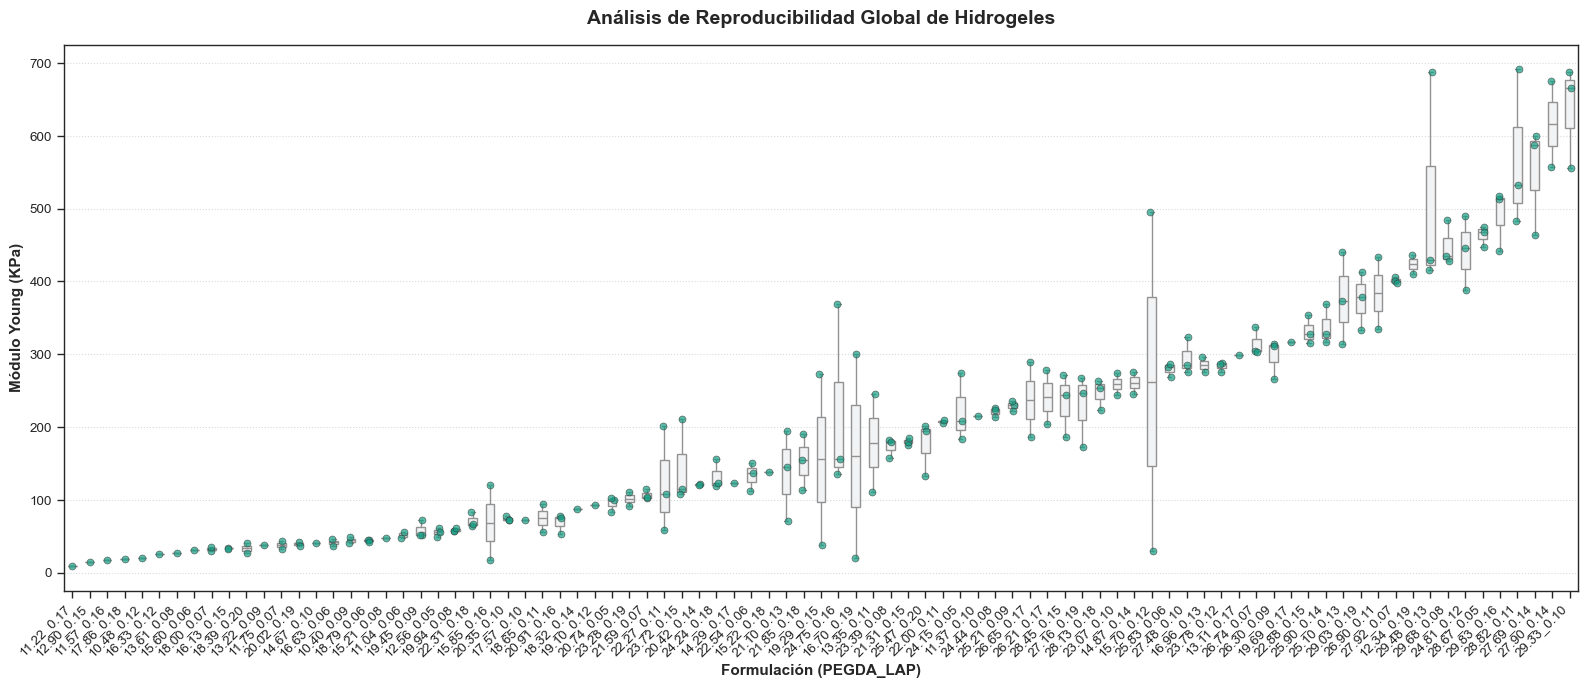

In [12]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

print("Generando análisis de reproducibilidad unificado en una sola gráfica...")


df_super_limpio["Receta_ID"] = (
    df_super_limpio["PEGDA (%)"].map(lambda x: f"{x:.2f}")
    + "_"
    + df_super_limpio["LAP (%)"].map(lambda x: f"{x:.2f}")
)


orden_recetas = (
    df_super_limpio.groupby("Receta_ID")[col_young].median().sort_values().index
)

sns.set_theme(style="ticks", context="paper", font_scale=1.1)

fig, ax = plt.subplots(figsize=(16, 7))

sns.boxplot(
    x="Receta_ID",
    y=col_young,
    data=df_super_limpio,
    order=orden_recetas,
    color="#F2F3F4",
    width=0.5,
    showfliers=False,
    ax=ax,
)

sns.stripplot(
    x="Receta_ID",
    y=col_young,
    data=df_super_limpio,
    order=orden_recetas,
    size=5,
    color="#16A085",
    alpha=0.7,
    jitter=True,
    linewidth=0.5,
    ax=ax,
)

ax.set_title(
    "Análisis de Reproducibilidad Global de Hidrogeles",
    fontsize=14,
    fontweight="bold",
    pad=15,
)
ax.set_ylabel("Módulo Young (KPa)", fontweight="bold", fontsize=11)
ax.set_xlabel("Formulación (PEGDA_LAP)", fontweight="bold", fontsize=11)

ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha="right")
ax.yaxis.grid(True, linestyle=":", alpha=0.6, color="#BDC3C7")
plt.tight_layout()

plt.savefig("Reproducibilidad_Global_SistemaLAP_Unico.png", dpi=300, bbox_inches="tight")
plt.show()

📅 Generando análisis completo de Reproducibilidad y Rigidez Inter-Sesión...


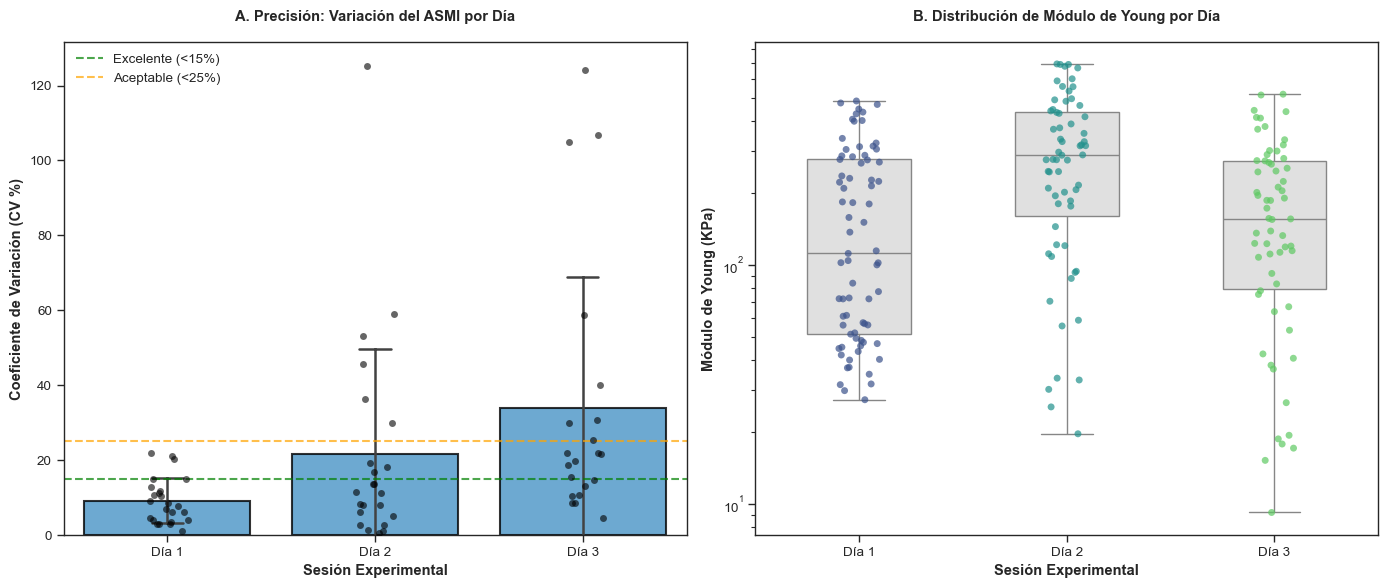


📊 RESUMEN DE VARIABILIDAD INTER-SESIÓN (ASMI)
              CV Medio (%)  Módulo Young Medio (KPa)  Desviación Young (±KPa)  Total Probetas
Etiqueta_Dia                                                                                 
Día 1                 9.18                    172.39                   138.07              73
Día 2                21.60                    305.34                   191.03              63
Día 3                33.81                    185.20                   132.27              62

💡 DATO CLAVE: El Módulo de Young promedio más bajo fue de 172.39 KPa, y el más alto de 305.34 KPa.
Recuerda: Si estos números son muy distintos, asegúrate de que no se deba simplemente a que fabricaste recetas distintas cada día.


In [13]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import pandas as pd

print("Generando análisis completo de Reproducibilidad y Rigidez Inter-Sesión...")

col_sesion = 'DIA ESTUDIO'

if col_sesion not in df_super_limpio.columns:
    print(f"ERROR: No encuentro la columna '{col_sesion}'.")
else:
    # 1. PREPARACIÓN DE ETIQUETAS
    df_super_limpio['Etiqueta_Dia'] = 'Día ' + df_super_limpio[col_sesion].astype(str)
    
    # 2. CÁLCULO DE MÉTRICAS (CV por receta y día)
    metricas_sesion = df_super_limpio.groupby(['Etiqueta_Dia', 'Receta_ID'])[col_young].agg(['mean', 'std', 'count']).reset_index()
    metricas_sesion = metricas_sesion[metricas_sesion['count'] > 1].copy()
    metricas_sesion['CV (%)'] = (metricas_sesion['std'] / metricas_sesion['mean']) * 100

    # 3. CREACIÓN DE LA FIGURA DE DOBLE PANEL (NIVEL TESIS Q1)
    fig, axes = plt.subplots(1, 2, figsize=(14, 6))
    sns.set_theme(style="ticks", context="paper", font_scale=1.1)

    # ================= PANEL 1: Coeficiente de Variación (Precisión) =================
    sns.barplot(x='Etiqueta_Dia', y='CV (%)', data=metricas_sesion, ax=axes[0],
                color="#3498DB", edgecolor="black", linewidth=1.5, capsize=0.15, errorbar="sd", alpha=0.8)
    sns.stripplot(x='Etiqueta_Dia', y='CV (%)', data=metricas_sesion, ax=axes[0],
                  color="black", size=5, jitter=True, alpha=0.6)
    
    axes[0].axhline(y=15, color='green', linestyle='--', linewidth=1.5, alpha=0.7, label='Excelente (<15%)')
    axes[0].axhline(y=25, color='orange', linestyle='--', linewidth=1.5, alpha=0.7, label='Aceptable (<25%)')
    
    axes[0].set_title("A. Precisión: Variación del ASMI por Día", fontweight='bold', pad=15)
    axes[0].set_ylabel("Coeficiente de Variación (CV %)", fontweight='bold')
    axes[0].set_xlabel("Sesión Experimental", fontweight='bold')
    axes[0].legend(loc="upper left")
    axes[0].set_ylim(bottom=0)

    # ================= PANEL 2: Módulo de Young Medio (Rigidez Global) =================
    sns.boxplot(x='Etiqueta_Dia', y=col_young, data=df_super_limpio, ax=axes[1],
                color="#E0E0E0", width=0.5, showfliers=False)
    sns.stripplot(x='Etiqueta_Dia', y=col_young, data=df_super_limpio, ax=axes[1],
                  palette="viridis", size=5, jitter=True, alpha=0.7)
    
    axes[1].set_title("B. Distribución de Módulo de Young por Día", fontweight='bold', pad=15)
    axes[1].set_ylabel("Módulo de Young (KPa)", fontweight='bold')
    axes[1].set_xlabel("Sesión Experimental", fontweight='bold')
    

    axes[1].set_yscale('log')

    plt.tight_layout()
    plt.savefig('Analisis_Dias_Completo_LAP.png', dpi=600, bbox_inches='tight')
    plt.show()

    # =====================================================================
    # 4. REPORTE ESTADÍSTICO PARA LA TESIS (Incluyendo Modulo de Young)
    # =====================================================================
    print("\n=======================================================")
    print("RESUMEN DE VARIABILIDAD INTER-SESIÓN (ASMI)")
    print("=======================================================")

    # Calculamos CV Medio
    resumen_cv = metricas_sesion.groupby('Etiqueta_Dia')['CV (%)'].agg(['mean']).rename(columns={'mean': 'CV Medio (%)'})
    
    # Calculamos Young Medio directamente de los datos limpios
    resumen_young = df_super_limpio.groupby('Etiqueta_Dia')[col_young].agg(['mean', 'std', 'count'])
    resumen_young.columns = ['Módulo Young Medio (KPa)', 'Desviación Young (±KPa)', 'Total Probetas']

    # Unimos todo en una tabla maestra
    tabla_final = pd.concat([resumen_cv, resumen_young], axis=1)
    
    print(tabla_final.round(2).to_string())

    print("\n=======================================================")
    # Conclusión automática basada en el Módulo de Young Medio
    max_young = tabla_final['Módulo Young Medio (KPa)'].max()
    min_young = tabla_final['Módulo Young Medio (KPa)'].min()
    
    print(f"💡 DATO CLAVE: El Módulo de Young promedio más bajo fue de {min_young:.2f} KPa, y el más alto de {max_young:.2f} KPa.")
    print("Recuerda: Si estos números son muy distintos, asegúrate de que no se deba simplemente a que fabricaste recetas distintas cada día.")

⏱️ Generando análisis de estabilidad intra-día (7 mins por muestra)...


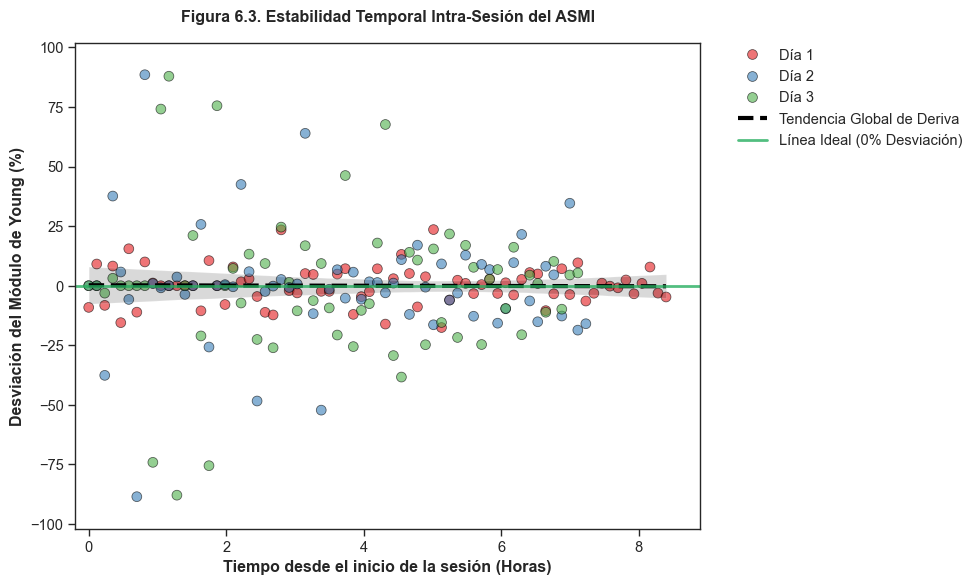


📈 RESULTADOS DE LA PRUEBA DE DERIVA INTRA-SESIÓN
Duración máxima de una sesión: 8.40 horas.
Pendiente de deriva: -0.050% de variación por cada HORA de uso continuo.
Valor p de significancia: 0.9432

💡 CONCLUSIÓN CIENTÍFICA PARA LA DEFENSA:
✅ 'El análisis demostró que el ASMI es estable en sesiones de alto rendimiento. La deriva instrumental observada fue de apenas -0.050% por hora (p = 0.9432), descartando problemas de fatiga del indentador o deshidratación severa de las placas de 96 pocillos durante las 8.4 horas que dura cada sesión experimental.'


In [67]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import pandas as pd
from scipy.stats import linregress

print("Generando análisis de estabilidad intra-día (7 mins por muestra)...")

# =====================================================================
# 0. CHEQUEOS DE SEGURIDAD PREVIOS
# =====================================================================
col_sesion = 'DIA ESTUDIO'

if 'Etiqueta_Dia' not in df_super_limpio.columns:
    df_super_limpio['Etiqueta_Dia'] = 'Día ' + df_super_limpio[col_sesion].astype(str)

df_deriva = df_super_limpio.copy()

# =====================================================================
# 1. CREACIÓN DEL EJE DE TIEMPO INTRA-DÍA
# =====================================================================
df_deriva['Orden_Intradia'] = df_deriva.groupby(col_sesion).cumcount()
df_deriva['Tiempo_Horas'] = (df_deriva['Orden_Intradia'] * 7) / 60

# =====================================================================
# 2. NORMALIZACIÓN (Desviación Relativa de cada mezcla)
# =====================================================================
medias_esperadas = df_deriva.groupby('Receta_ID')[col_young].transform('mean')
df_deriva['Desviacion_Relativa (%)'] = ((df_deriva[col_young] - medias_esperadas) / medias_esperadas) * 100

# Limpiamos NaNs o infinitos que harían fallar a la regresión lineal
df_deriva = df_deriva.replace([np.inf, -np.inf], np.nan).dropna(subset=['Tiempo_Horas', 'Desviacion_Relativa (%)'])

# =====================================================================
# 3. DIBUJO DE LA GRÁFICA (Estabilidad Intra-Sesión)
# =====================================================================
plt.figure(figsize=(10, 6))
sns.set_theme(style="ticks", context="paper", font_scale=1.2)

sns.scatterplot(
    x='Tiempo_Horas', 
    y='Desviacion_Relativa (%)', 
    hue='Etiqueta_Dia',      
    data=df_deriva,
    palette='Set1',          
    alpha=0.6,
    edgecolor="black",
    s=50
)

sns.regplot(
    x='Tiempo_Horas', 
    y='Desviacion_Relativa (%)', 
    data=df_deriva,
    scatter=False,           
    color="black",           
    line_kws={'linewidth': 3, 'linestyle': '--'},
    label='Tendencia Global de Deriva'
)

plt.axhline(0, color='#27AE60', linewidth=2, linestyle='-', alpha=0.8, label='Línea Ideal (0% Desviación)')

# Estética
plt.title("Figura 6.3. Estabilidad Temporal Intra-Sesión del ASMI", fontweight='bold', pad=15)
plt.xlabel("Tiempo desde el inicio de la sesión (Horas)", fontweight='bold')
plt.ylabel("Desviación del Módulo de Young (%)", fontweight='bold')

plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', borderaxespad=0.)

if len(df_deriva) > 0:
    limite_y = df_deriva['Desviacion_Relativa (%)'].quantile(0.98) 
    plt.ylim(-abs(limite_y)*1.5, abs(limite_y)*1.5) # Absoluto para evitar problemas si es negativo
    plt.xlim(-0.2, df_deriva['Tiempo_Horas'].max() + 0.5) 

plt.tight_layout()
plt.savefig('Figura_6_3_Deriva_Intradia_LAP.png', dpi=600, bbox_inches='tight')
plt.show()

# ==============
# 4. AUDITORÍA
# ==============
if len(df_deriva) > 1:
    slope, intercept, r_value, p_value, std_err = linregress(df_deriva['Tiempo_Horas'], df_deriva['Desviacion_Relativa (%)'])

    print("\n=======================================================")
    print("RESULTADOS DE LA PRUEBA DE DERIVA INTRA-SESIÓN")
    print("=======================================================")
    print(f"Duración máxima de una sesión: {df_deriva['Tiempo_Horas'].max():.2f} horas.")
    print(f"Pendiente de deriva: {slope:.3f}% de variación por cada HORA de uso continuo.")
    print(f"Valor p de significancia: {p_value:.4f}")

    print("\n💡 CONCLUSIÓN CIENTÍFICA PARA LA DEFENSA:")
    if p_value > 0.05 or abs(slope) < 1.0:
        print(f"✅ 'El análisis demostró que el ASMI es estable en sesiones de alto rendimiento. La deriva instrumental observada fue de apenas {slope:.3f}% por hora (p = {p_value:.4f}), descartando problemas de fatiga del indentador o deshidratación severa de las placas de 96 pocillos durante las {df_deriva['Tiempo_Horas'].max():.1f} horas que dura cada sesión experimental.'")
    else:
        print(f"⚠️ 'Se detectó una leve tendencia a la deriva térmica/deshidratación de {slope:.3f}% por hora. Esto significa que las muestras medidas al final tienden a dar valores ligeramente distintos.'")
else:
    print("⚠️ No hay suficientes datos limpios para calcular la deriva.")

Generando análisis termodinámico completo (Sistema PEGDA - LAP - Agua)...


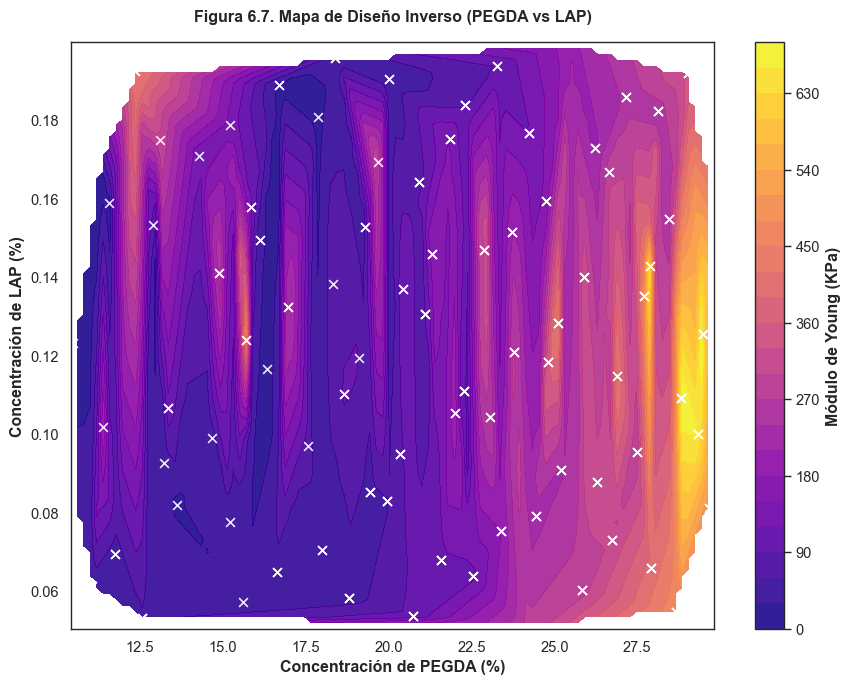

Generando Superficie 3D Interactiva con Plotly...


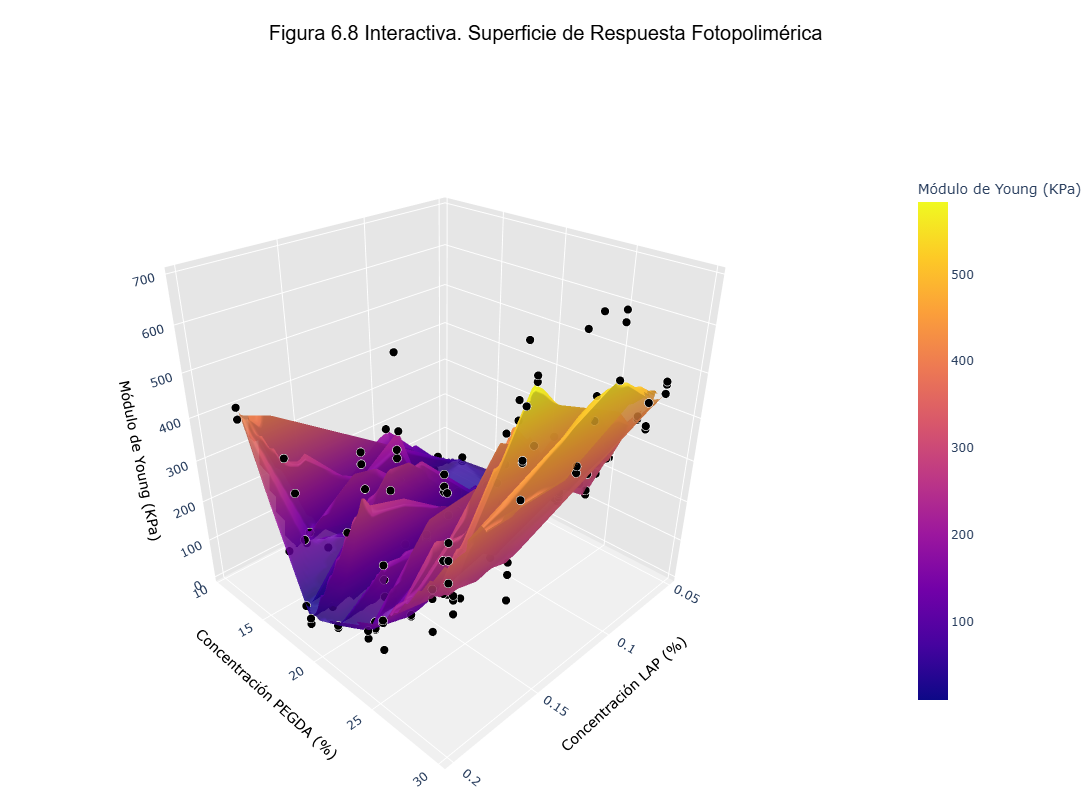

In [26]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import pandas as pd
from scipy.interpolate import griddata

print("Generando análisis termodinámico completo (Sistema PEGDA - LAP - Agua)...")

# =====================================================================
# 1. PREPARACIÓN DE DATOS
# =====================================================================
if 'Agua (%)' not in df_super_limpio.columns:
    df_super_limpio['Agua (%)'] = 100 - df_super_limpio['PEGDA (%)'] - df_super_limpio['LAP (%)']

df_super_limpio['Ratio_PEGDA_Agua'] = df_super_limpio['PEGDA (%)'] / df_super_limpio['Agua (%)']

# Ejes principales (Los reactivos activos)

x = df_super_limpio['PEGDA (%)']
y = df_super_limpio['LAP (%)']
z = df_super_limpio[col_young] 

# =====================================================================
# FIGURA : MAPA DE CALOR (PEGDA vs LAP)
# =====================================================================
# Creamos la malla matemática
xi = np.linspace(x.min(), x.max(), 100)
yi = np.linspace(y.min(), y.max(), 100)
xi, yi = np.meshgrid(xi, yi)

# Interpolamos la superficie real
zi = griddata((x, y), z, (xi, yi), method='linear')

plt.figure(figsize=(9, 7))
sns.set_theme(style="white", context="paper", font_scale=1.2)

# Heatmap
contour = plt.contourf(xi, yi, zi, levels=25, cmap='plasma', alpha=0.9)
cbar = plt.colorbar(contour)
cbar.set_label('Módulo de Young (KPa)', fontweight='bold')

# Puntos reales
plt.scatter(x, y, c='white', s=40, marker='x', alpha=0.9)

plt.title("Figura 6.7. Mapa de Diseño Inverso (PEGDA vs LAP)", fontweight='bold', pad=15)
plt.xlabel("Concentración de PEGDA (%)", fontweight='bold')
plt.ylabel("Concentración de LAP (%)", fontweight='bold')
plt.legend(loc="upper left")

plt.tight_layout()
plt.savefig('Figura_6_7_Heatmap_PEGDA_LAP.png', dpi=300, bbox_inches='tight')
plt.show()

# =====================================================================
# FIGURA : SUPERFICIE DE RESPUESTA 3D (PEGDA vs LAP vs Young)
# =====================================================================
import numpy as np
import pandas as pd
from scipy.interpolate import griddata
import plotly.graph_objects as go

print("Generando Superficie 3D Interactiva con Plotly...")

# =====================================================================
# 1. PREPARACIÓN DE DATOS Y ASIGNACIÓN DE EJES
# =====================================================================
x_real = df_super_limpio['LAP (%)']
y_real = df_super_limpio['PEGDA (%)'] 
z_real = df_super_limpio[col_young]

# Creamos la malla matemática (grid) para interpolar la superficie
xi = np.linspace(x_real.min(), x_real.max(), 100)
yi = np.linspace(y_real.min(), y_real.max(), 100)
xi_mesh, yi_mesh = np.meshgrid(xi, yi)

# Interpolamos la superficie real
zi_mesh = griddata((x_real, y_real), z_real, (xi_mesh, yi_mesh), method='linear')

# =====================================================================
# 2. CREACIÓN DEL GRÁFICO INTERACTIVO (PLOTLY)
# =====================================================================
fig = go.Figure()

# A) Añadimos la "Sábana" o Superficie 3D
fig.add_trace(go.Surface(
    x=xi_mesh,
    y=yi_mesh,
    z=zi_mesh,
    colorscale='Plasma',
    opacity=0.85,
    name='Superficie de Tendencia',
    colorbar=dict(title='Módulo de Young (KPa)', len=0.75)
))

# B) Añadimos los Puntos Experimentales Reales flotando en el espacio
fig.add_trace(go.Scatter3d(
    x=x_real,
    y=y_real,
    z=z_real,
    mode='markers',
    marker=dict(
        size=5,
        color='black',
        symbol='circle',
        line=dict(color='white', width=1.5)
    ),
    name='Probetas Reales',
    # Esto define lo que ves al pasar el ratón por encima (Hover tool)
    hovertemplate="<b>LAP:</b> %{x:.2f}%<br>" +
                  "<b>PEGDA:</b> %{y:.1f}%<br>" +
                  "<b>Módulo:</b> %{z:.2f} KPa<extra></extra>"
))

# =====================================================================
# 3. ESTÉTICA Y CONTROLES DE LA CÁMARA
# =====================================================================
fig.update_layout(
    title=dict(
        text='Figura 6.8 Interactiva. Superficie de Respuesta Fotopolimérica',
        font=dict(size=20, family='Arial', color='black'),
        x=0.5 # Centrado
    ),
    scene=dict(
        xaxis_title=dict(text='Concentración LAP (%)', font=dict(color='black', size=14)),
        yaxis_title=dict(text='Concentración PEGDA (%)', font=dict(color='black', size=14)),
        zaxis_title=dict(text='Módulo de Young (KPa)', font=dict(color='black', size=14)),
        
        # Color del fondo de los ejes para que se vea limpio
        xaxis=dict(backgroundcolor="rgb(230, 230,230)", gridcolor="white", showbackground=True, zerolinecolor="white"),
        yaxis=dict(backgroundcolor="rgb(230, 230,230)", gridcolor="white", showbackground=True, zerolinecolor="white"),
        zaxis=dict(backgroundcolor="rgb(240, 240,240)", gridcolor="white", showbackground=True, zerolinecolor="white"),
        
        # Posición inicial de la cámara
        camera=dict(
            eye=dict(x=1.5, y=1.5, z=1.2)
        )
    ),
    width=900,
    height=800,
    margin=dict(l=0, r=0, b=0, t=80)
)

# Mostrar el gráfico interactivo en el Jupyter Notebook
fig.show()

# Opcional: Guardarlo como un archivo HTML para abrirlo en cualquier navegador web
fig.write_html("Figura_6_8_Interactiva.html")

Generando análisis 2D con escala de color optimizada para visualización de tendencias...


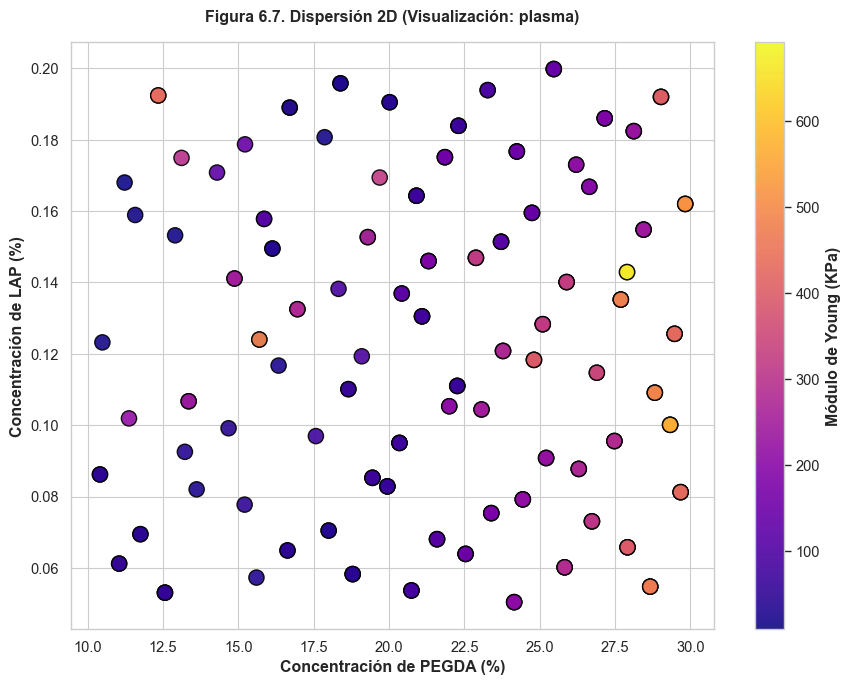

In [27]:
import matplotlib.pyplot as plt
import seaborn as sns

print("Generando análisis 2D con escala de color optimizada para visualización de tendencias...")

# =====================================================================
# 1. PREPARACIÓN DE DATOS
# =====================================================================
x = df_super_limpio['PEGDA (%)']
y = df_super_limpio['LAP (%)']
z = df_super_limpio[col_young] 

# =====================================================================
# 2. SELECCIÓN DE LA ESCALA DE COLOR
# =====================================================================

opcion_color = 'plasma' 

# =====================================================================
# FIGURA 2D : DISPERSIÓN (PEGDA vs LAP)
# =====================================================================
plt.figure(figsize=(9, 7))

sns.set_theme(style="whitegrid", context="paper", font_scale=1.2) 

# Gráfico de dispersión (Scatter)
scatter = plt.scatter(x, y, 
                      c=z,                   
                      cmap=opcion_color,     
                      s=120,                 
                      edgecolors='black',    
                      linewidths=1,
                      alpha=0.9)


cbar = plt.colorbar(scatter)
cbar.set_label(f'Módulo de Young (KPa)', fontweight='bold')

# Etiquetas y títulos
plt.title(f"Figura 6.7. Dispersión 2D (Visualización: {opcion_color})", fontweight='bold', pad=15)
plt.xlabel("Concentración de PEGDA (%)", fontweight='bold')
plt.ylabel("Concentración de LAP (%)", fontweight='bold')

plt.tight_layout()

# Guardamos la imagen
plt.savefig(f'Figura_6_7_Puntos_{opcion_color}.png', dpi=600, bbox_inches='tight')
plt.show()

Generando Gráfico 3D Interactivo de Puntos con Plotly...


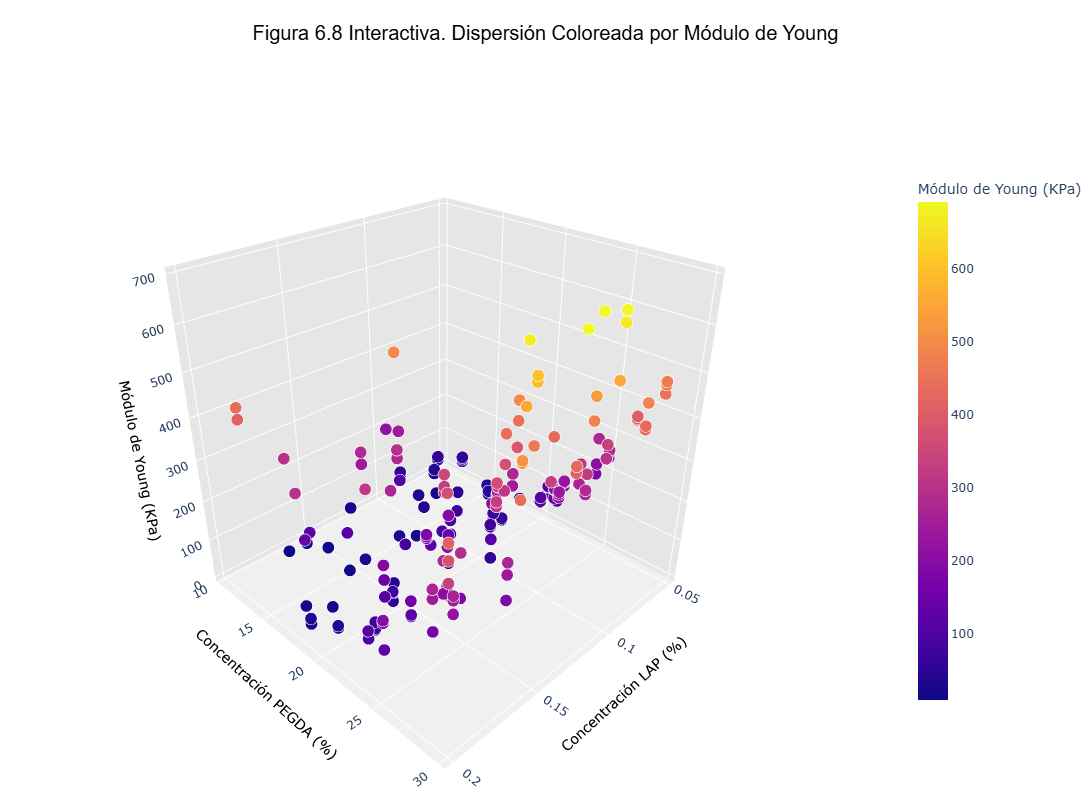

In [28]:
import plotly.graph_objects as go

print("Generando Gráfico 3D Interactivo de Puntos con Plotly...")

# =====================================================================
# 1. PREPARACIÓN DE DATOS
# =====================================================================
# Asumo que df_super_limpio y col_young ya están definidos previamente
x_real = df_super_limpio['LAP (%)']
y_real = df_super_limpio['PEGDA (%)'] 
z_real = df_super_limpio[col_young]

# =====================================================================
# 2. CREACIÓN DEL GRÁFICO INTERACTIVO (PLOTLY)
# =====================================================================
fig = go.Figure()

# Añadimos SOLO los Puntos Experimentales Reales
fig.add_trace(go.Scatter3d(
    x=x_real,
    y=y_real,
    z=z_real,
    mode='markers',
    marker=dict(
        size=7,                  
        color=z_real,           
        colorscale='plasma',   
        showscale=True,          
        colorbar=dict(title='Módulo de Young (KPa)', len=0.75),
        symbol='circle',
        line=dict(color='white', width=1) 
    ),
    name='Probetas Reales',
    
    hovertemplate="<b>LAP:</b> %{x:.2f}%<br>" +
                  "<b>PEGDA:</b> %{y:.1f}%<br>" +
                  "<b>Módulo:</b> %{z:.2f} KPa<extra></extra>"
))

# =====================================================================
# 3. ESTÉTICA Y CONTROLES DE LA CÁMARA
# =====================================================================
fig.update_layout(
    title=dict(
        text='Figura 6.8 Interactiva. Dispersión Coloreada por Módulo de Young',
        font=dict(size=20, family='Arial', color='black'),
        x=0.5 # Centrado
    ),
    scene=dict(
        xaxis_title=dict(text='Concentración LAP (%)', font=dict(color='black', size=14)),
        yaxis_title=dict(text='Concentración PEGDA (%)', font=dict(color='black', size=14)),
        zaxis_title=dict(text='Módulo de Young (KPa)', font=dict(color='black', size=14)),
        
        
        xaxis=dict(backgroundcolor="rgb(230, 230,230)", gridcolor="white", showbackground=True, zerolinecolor="white"),
        yaxis=dict(backgroundcolor="rgb(230, 230,230)", gridcolor="white", showbackground=True, zerolinecolor="white"),
        zaxis=dict(backgroundcolor="rgb(240, 240,240)", gridcolor="white", showbackground=True, zerolinecolor="white"),
        
        camera=dict(
            eye=dict(x=1.5, y=1.5, z=1.2)
        )
    ),
    width=900,
    height=800,
    margin=dict(l=0, r=0, b=0, t=80)
)

# Mostrar el gráfico interactivo en el Jupyter Notebook
fig.show()

# Opcional: Guardarlo como un archivo HTML para abrirlo en cualquier navegador web
fig.write_html("Figura_6_8_Interactiva_Solo_Puntos.html")